# Week 1 Practice Tutorial: Regression & Gradient Descent

**MATH3881/5881 — Statistical Machine Learning Theory**

This notebook is the computational companion to the Week 1 *Theory Tutorial*.
We revisit the same four ideas — empirical risk minimisation, linear regression,
logistic regression, and gradient descent — but in code, applying the formulas you
derived by hand and checking them against `scikit-learn`.

**How to run.** Works the same locally or on Google Colab — the `data_path` helper
below uses local files when run from the repository, and pulls the CSVs from the
public GitHub raw URLs when run on Colab. No setup steps required.

**Datasets.**

`datasets/housing.csv` — Boston-style housing data (506 rows). Key columns used here:
- `rm` — average number of rooms per dwelling
- `lstat` — % of the population classified as "lower status"
- `medv` — median home value ($1000s) *— regression target*
- Other features used in the ridge demo: `crim, indus, nox, age, dis, tax, ptratio`.
- The ethically problematic `b` column of the original dataset has been removed.

`datasets/iris.csv` — Fisher's iris data (150 rows, **headerless**). Four measurements (cm) followed by three one-hot species columns:
- features: `sepal_length, sepal_width, petal_length, petal_width`
- species (one-hot): `setosa, versicolor, virginica`
- The logistic-regression part uses `petal_length` and `petal_width` to classify *versicolor* vs *virginica*.

> Cells marked **▶ Exercise** are for you to complete. In the *solutions* notebook they
> are filled in.

## 0. Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)

IN_COLAB = "google.colab" in sys.modules
GH_RAW = "https://raw.githubusercontent.com/9yifanchen9/MATH3881-5881/main/datasets"

def data_path(name):
    "Local file when running from the repo; GitHub raw URL on Colab (or fallback)."
    if not IN_COLAB:
        for base in [Path.cwd(), *Path.cwd().parents]:
            p = base / "datasets" / name
            if p.exists():
                return str(p)
    return f"{GH_RAW}/{name}"

## 1. Linear regression

**Goal.** Predict housing prices (`medv`) from one or more features by minimising the
squared error. We start with one feature, add a non-linear term, then use many
features at once with ridge regularisation.

In [2]:
housing = pd.read_csv(data_path("housing.csv"))
print("shape:", housing.shape)
housing[["rm", "lstat", "medv"]].head()

shape: (506, 13)


,rm,lstat,medv
0,6.575,4.98,24.0
1,6.421,9.14,21.6
2,7.185,4.03,34.7
3,6.998,2.94,33.4
4,7.147,5.33,36.2


### 1.1 One feature: `medv` vs `rm`

**Goal.** Find the line $\hat y = \hat\theta_0 + \hat\theta_1\,x$ that best fits the
data, using the closed-form least-squares formula you derived in **Problem 1** of the
theory tutorial:
$$
\hat\theta_1 \;=\; \frac{\sum_i (x^{(i)} - \bar x)\,(y^{(i)} - \bar y)}{\sum_i (x^{(i)} - \bar x)^2},
\qquad
\hat\theta_0 \;=\; \bar y - \hat\theta_1\,\bar x.
$$
Then check the answer against `scikit-learn`.

from scratch:  intercept = -34.671,  slope = 9.102
scikit-learn:  intercept = -34.671,  slope = 9.102


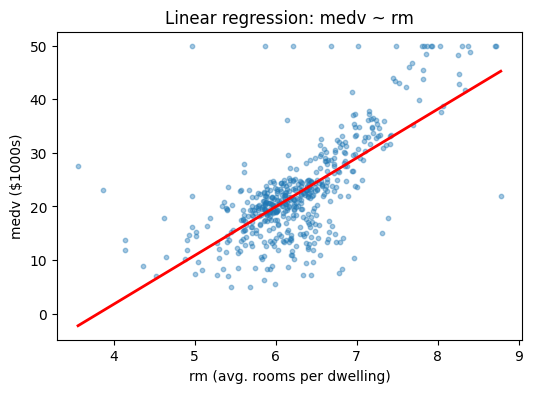

In [3]:
x = housing["rm"].values
y = housing["medv"].values

# Least-squares formulas from Problem 1 of the theory tutorial
x_mean, y_mean = x.mean(), y.mean()
theta_1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
theta_0 = y_mean - theta_1 * x_mean
print(f"from scratch:  intercept = {theta_0:.3f},  slope = {theta_1:.3f}")

# Check against scikit-learn
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(x[:, None], y)
print(f"scikit-learn:  intercept = {lr.intercept_:.3f},  slope = {lr.coef_[0]:.3f}")

# Plot
xs = np.linspace(x.min(), x.max(), 100)
plt.scatter(x, y, s=10, alpha=0.4)
plt.plot(xs, theta_0 + theta_1 * xs, "r-", lw=2)
plt.xlabel("rm (avg. rooms per dwelling)"); plt.ylabel("medv ($1000s)")
plt.title("Linear regression: medv ~ rm"); plt.show()

### 1.2 Add a nonlinear feature: `medv` vs `lstat`, with `lstat`²

**Goal.** A straight line underfits `medv` vs `lstat` because the relationship is
curved. Add `lstat`² as a second feature; the model is still *linear in the
parameters*, but it can now bend:
$$
\hat y \;=\; \theta_0 + \theta_1\,\texttt{lstat} + \theta_2\,\texttt{lstat}^2.
$$
With more than one parameter, the easiest way to solve the least-squares problem in
code is `np.linalg.lstsq`, which returns the $\hat\theta$ that minimises
$\|y - X\theta\|^2$ for a design matrix $X$ whose first column is all ones (for the
intercept) and remaining columns are the features.

To compare the two fits, the cell below reports the **residual sum of squares (RSS)**
on the training data:
$$
\mathrm{RSS} \;=\; \sum_{i=1}^n \big(y^{(i)} - \hat y^{(i)}\big)^2.
$$
A smaller RSS means the fitted curve passes closer to the data points.

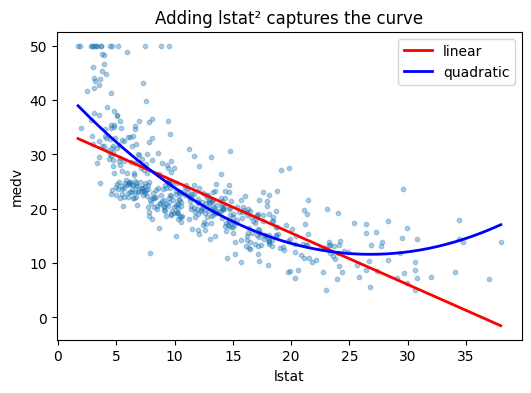

RSS linear    = 19472
RSS quadratic = 15347


In [4]:
xl = housing["lstat"].values

# Linear:     medv = theta_0 + theta_1 * lstat
X_lin  = np.column_stack([np.ones(len(xl)), xl])
theta_lin  = np.linalg.lstsq(X_lin, y, rcond=None)[0]

# Quadratic:  medv = theta_0 + theta_1 * lstat + theta_2 * lstat^2
X_quad = np.column_stack([np.ones(len(xl)), xl, xl ** 2])
theta_quad = np.linalg.lstsq(X_quad, y, rcond=None)[0]

# Plot
xs = np.linspace(xl.min(), xl.max(), 200)
plt.scatter(xl, y, s=10, alpha=0.35)
plt.plot(xs, theta_lin[0] + theta_lin[1]*xs, "r-", lw=2, label="linear")
plt.plot(xs, theta_quad[0] + theta_quad[1]*xs + theta_quad[2]*xs**2, "b-", lw=2, label="quadratic")
plt.legend(); plt.xlabel("lstat"); plt.ylabel("medv")
plt.title("Adding lstat² captures the curve"); plt.show()

# Residual sum of squares — lower is a better fit on the training data
print(f"RSS linear    = {np.sum((y - X_lin  @ theta_lin )**2):.0f}")
print(f"RSS quadratic = {np.sum((y - X_quad @ theta_quad)**2):.0f}")

### 1.3 Ridge regression with many features

**Goal.** When we fit many features at once, parameter estimates can grow large and
unstable. *Ridge regression* (lecture notes, §1.8) adds a penalty $\lambda\,\|\theta\|^2$
on parameter size:
$$
\hat\theta_\lambda \;=\; \arg\min_{\theta} \;\|y - X\theta\|^2 \;+\; \lambda\,\|\theta\|^2.
$$
Larger $\lambda$ shrinks every coefficient toward zero. We use
`sklearn.linear_model.Ridge` and watch how each feature's coefficient changes as
$\lambda$ grows.

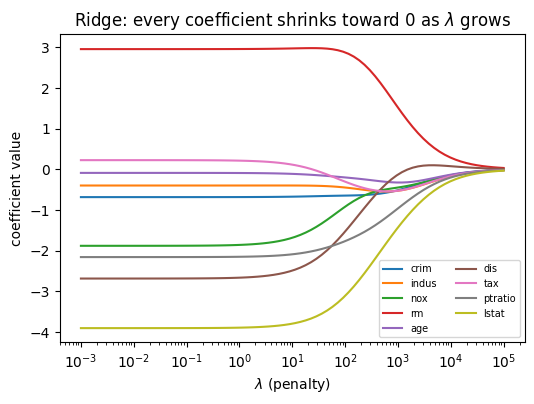

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

features = ["crim", "indus", "nox", "rm", "age", "dis", "tax", "ptratio", "lstat"]
Xs = StandardScaler().fit_transform(housing[features].values)
yc = y - y.mean()                            # centre y so a separate intercept isn't needed

lambdas = np.logspace(-3, 5, 80)
coefs   = np.array([Ridge(alpha=lam).fit(Xs, yc).coef_ for lam in lambdas])

for j, name in enumerate(features):
    plt.plot(lambdas, coefs[:, j], label=name)
plt.xscale("log"); plt.xlabel(r"$\lambda$ (penalty)")
plt.ylabel("coefficient value")
plt.title(r"Ridge: every coefficient shrinks toward 0 as $\lambda$ grows")
plt.legend(fontsize=7, ncol=2); plt.show()

### ▶ Exercise 1: fit `medv` from both `rm` and `lstat`

Build the design matrix $X$ with three columns — a column of ones (intercept), `rm`,
and `lstat` — fit by least squares using `np.linalg.lstsq`, and check that the three
coefficients $(\theta_0, \theta_1, \theta_2)$ match `LinearRegression`.

In [13]:
# DONE: Build X2 with three columns [1, rm, lstat] (one row per observation),
#       fit by  np.linalg.lstsq(X2, y, rcond=None)[0],
#       print the coefficients and compare with LinearRegression().
xr = housing["rm"].values
xl = housing["lstat"].values
X2 = np.column_stack([np.ones(len(xr)), xr, xl])

print(np.linalg.lstsq(X2, y, rcond=None)[0])

from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X2, y)
print(f"scikit-learn:  intercept = {lr.intercept_:.3f},  coefficients = {lr.coef_}")

[-1.35827281  5.09478798 -0.64235833]
scikit-learn:  intercept = -1.358,  coefficients = [ 0.          5.09478798 -0.64235833]


## 2. Gradient descent

**Goal.** Sometimes there is no closed-form formula for the best parameters (we'll see
this for logistic regression in §3). In those cases we minimise the loss
*iteratively*: start somewhere, repeatedly take a small step in the direction that
reduces it. Here we implement it for least squares — where we *can* check the answer
against the closed form.

### 2.1 Implementing gradient descent

**Goal.** Take the single gradient-descent step you computed by hand in **Problem 3**
of the theory tutorial and put it in a loop. The update rule is
$$
\theta^{(t+1)} \;=\; \theta^{(t)} \;-\; \alpha\,\nabla_\theta C(\theta^{(t)}),
$$
where $\alpha > 0$ is the *learning rate*. For least squares with $C(\theta) =
\tfrac{1}{n}\|y - X\theta\|^2$, the gradient (lecture notes, §1.9) is
$$
\nabla_\theta C(\theta) \;=\; \tfrac{2}{n}\,X^\top(X\theta - y).
$$
We standardise the input first so the gradient is well-scaled.

In [ ]:
def gradient_descent_lr(X, y, alpha, n_iter=200):
    "Gradient descent for least squares:  theta <- theta - alpha * (2/n) X^T (X theta - y)."
    n, theta = len(y), np.zeros(X.shape[1])
    losses = []
    for _ in range(n_iter):
        residual = X @ theta - y
        gradient = (2.0 / n) * X.T @ residual
        theta    = theta - alpha * gradient
        losses.append(np.mean(residual ** 2))
    return theta, np.array(losses)

# Standardise rm:  subtract mean, divide by std
xr     = housing["rm"].values
xr_std = (xr - xr.mean()) / xr.std()
X      = np.column_stack([np.ones(len(xr_std)), xr_std])    # intercept column + feature

theta_gd, losses = gradient_descent_lr(X, y, alpha=0.3, n_iter=80)
theta_cf         = np.linalg.lstsq(X, y, rcond=None)[0]      # closed-form, for comparison

print(f"gradient descent: {np.round(theta_gd, 3)}")
print(f"closed form:      {np.round(theta_cf, 3)}")

plt.plot(losses); plt.xlabel("iteration"); plt.ylabel("training MSE")
plt.title("GD converges to the closed-form solution"); plt.show()

### 2.2 Effect of the learning rate

**Goal.** Too small $\alpha$ → slow convergence; too large → divergence. See it.

In [ ]:
for alpha in [0.05, 0.2, 0.5, 1.02]:
    _, h = gradient_descent_lr(X, y, alpha=alpha, n_iter=60)
    plt.plot(h, label=f"α = {alpha}")
plt.yscale("log"); plt.xlabel("iteration"); plt.ylabel("training MSE (log scale)")
plt.title("Learning rate: too small → slow, too large → divergence")
plt.legend(); plt.show()

## 3. Logistic regression

**Goal.** Use logistic regression to classify two overlapping iris species
(*versicolor* vs *virginica*) from petal length and width, then evaluate the
classifier and explore the decision threshold from **Problem 2**.

### 3.1 Train logistic regression by gradient descent

**Goal.** Apply the gradient-descent step you did by hand in **Problem 3**
repeatedly, this time on real data. Recall the model and gradient from the lecture
notes (§§1.5 and 1.9):
$$
\hat y \;=\; \sigma(X\theta), \qquad
\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad
\nabla_\theta C(\theta) \;=\; \tfrac{1}{n}\,X^\top\!\bigl(\hat y - y\bigr),
$$
where $C$ is the binary cross-entropy loss.

In [ ]:
iris = pd.read_csv(
    data_path("iris.csv"), header=None,
    names=["sepal_length", "sepal_width", "petal_length", "petal_width",
           "setosa", "versicolor", "virginica"],
)
sub  = iris[iris["setosa"] == 0]                          # drop setosa  ->  100 rows
Xlog = sub[["petal_length", "petal_width"]].values
ylog = sub["virginica"].values.astype(float)              # 1 = virginica, 0 = versicolor

# Standardise the two features, then add an intercept column
mu, sd = Xlog.mean(0), Xlog.std(0)
Z      = (Xlog - mu) / sd
X      = np.column_stack([np.ones(len(Z)), Z])

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def bce(X, y, theta):
    p   = sigmoid(X @ theta); eps = 1e-12
    return float(-np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps)))

def gradient_descent_logreg(X, y, alpha=0.5, n_iter=3000):
    "GD for logistic regression:  theta <- theta - alpha * (1/n) X^T (sigmoid(X theta) - y)."
    theta, losses = np.zeros(X.shape[1]), []
    for _ in range(n_iter):
        p        = sigmoid(X @ theta)
        gradient = (X.T @ (p - y)) / len(y)
        theta    = theta - alpha * gradient
        losses.append(bce(X, y, theta))
    return theta, np.array(losses)

theta_log, losses = gradient_descent_logreg(X, ylog)
print("theta (from scratch):", np.round(theta_log, 3))

plt.plot(losses); plt.xlabel("iteration"); plt.ylabel("binary cross-entropy")
plt.title("Logistic regression training loss"); plt.show()

### 3.2 Decision boundary and evaluation

**Goal.** From **Problem 2** of the theory tutorial, the decision boundary is the line
$$
\hat\theta_0 + \hat\theta_1\,z_1 + \hat\theta_2\,z_2 \;=\; \log\frac{\tau}{1-\tau}.
$$
At the default threshold $\tau = 0.5$ the right-hand side is $0$. We plot this line on
top of the two-class scatter, then report accuracy, precision, recall and a ROC
curve.

In [ ]:
# Boundary at tau = 0.5:  theta_0 + theta_1 z_1 + theta_2 z_2 = 0
z1 = np.linspace(Z[:, 0].min() - 0.5, Z[:, 0].max() + 0.5, 100)
z2 = -(theta_log[0] + theta_log[1] * z1) / theta_log[2]

plt.scatter(Z[ylog == 0, 0], Z[ylog == 0, 1], s=20, label="versicolor")
plt.scatter(Z[ylog == 1, 0], Z[ylog == 1, 1], s=20, label="virginica")
plt.plot(z1, z2, "k--", label=r"boundary ($\tau=0.5$)")
plt.xlabel("petal_length (standardised)"); plt.ylabel("petal_width (standardised)")
plt.title("Logistic decision boundary"); plt.legend(); plt.show()

In [ ]:
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, roc_curve, auc)

p    = sigmoid(X @ theta_log)
yhat = (p > 0.5).astype(int)

print("accuracy :", round(accuracy_score(ylog, yhat), 3))
print("precision:", round(precision_score(ylog, yhat), 3))
print("recall   :", round(recall_score(ylog, yhat), 3))
print("confusion matrix  [[TN FP], [FN TP]]:\n", confusion_matrix(ylog, yhat))

fpr, tpr, _ = roc_curve(ylog, p)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], "k:")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC curve"); plt.legend(); plt.show()

### ▶ Exercise 2: threshold sweep

Sweep $\tau \in \{0.3,\,0.5,\,0.7\}$ and print precision and recall at each. How do
they move as $\tau$ changes? (Recall **Problem 2(b)** of the theory tutorial:
$\hat y > \tau$ shifts the decision boundary parallel to itself, so a smaller $\tau$
classifies more points as positive.)

In [ ]:
# TODO: for each tau in [0.3, 0.5, 0.7], threshold the probabilities p at tau
#       and print precision_score and recall_score from sklearn.metrics.